# Training Passive Liveness Detection Model
Notebook ini dibuat untuk melatih model mendeteksi Liveness (Live vs Spoof).

In [3]:
import os
import cv2
import numpy as np
import gc
from mtcnn import MTCNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import pickle

detector = MTCNN()

In [4]:
def apply_clahe_and_resize(face, size=(128, 128)):
    lab = cv2.cvtColor(face, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    face = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    face = cv2.resize(face, size, interpolation=cv2.INTER_AREA)
    return face.astype("float32")

def detect_and_preprocess_face(img):
    h, w = img.shape[:2]
    scale = 640 / max(h, w)
    if scale < 1:
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
        
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(rgb)
    results = [r for r in results if r['confidence'] >= 0.8]
    
    if len(results) > 0:
        results = sorted(results, key=lambda x: x['box'][2] * x['box'][3], reverse=True)
        result = results[0]
        x, y, w, h = result['box']
        pad = int(min(w, h) * 0.1)
        x1, y1 = max(0, x-pad), max(0, y-pad)
        x2, y2 = min(rgb.shape[1], x+w+pad), min(rgb.shape[0], y+h+pad)
        face = rgb[y1:y2, x1:x2]
    else:
        # Jika wajah tidak terdeteksi, asumsikan gambar sudah pre-cropped
        face = rgb
        
    if face.size == 0:
        return None
        
    return apply_clahe_and_resize(face)

In [5]:
def load_dataset(base_folder):
    images = []
    labels = []
    skipped = 0
    classes = ['live', 'spoof']
    
    print(f"Loading from {base_folder}...")
    for class_name in classes:
        folder_path = os.path.join(base_folder, class_name)
        if not os.path.isdir(folder_path):
            continue
            
        files = os.listdir(folder_path)
        used = 0
        for i, name in enumerate(files):
            if not name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
                
            img_path = os.path.join(folder_path, name)
            img = cv2.imread(img_path)
            if img is None:
                skipped += 1
                continue
                
            try:
                processed_img = detect_and_preprocess_face(img)
            except Exception as e:
                skipped += 1
                continue
                
            if processed_img is not None:
                images.append(processed_img)
                labels.append(class_name)
                used += 1
            else:
                skipped += 1
                
            if i % 50 == 0:
                print(f"Processed {i}/{len(files)} for {class_name}", end="\r")
                gc.collect()
                
        print(f"\n {class_name}: {used} images loaded.")
        
    return np.array(images, dtype="float32"), np.array(labels)

# Memuat data 
x_train, y_train_labels = load_dataset('Dataset/Dataset_liveness/train')
x_test, y_test_labels = load_dataset('Dataset/Dataset_liveness/test')

print("x_train shape :", x_train.shape)
print("x_test shape  :", x_test.shape)

Loading from Dataset/Dataset_liveness/train...
Processed 2050/2055 for live
 live: 2055 images loaded.
Processed 2500/2525 for spoof
 spoof: 2525 images loaded.
Loading from Dataset/Dataset_liveness/test...
Processed 500/514 for live
 live: 514 images loaded.
Processed 600/631 for spoof
 spoof: 631 images loaded.
x_train shape : (4580, 128, 128, 3)
x_test shape  : (1145, 128, 128, 3)


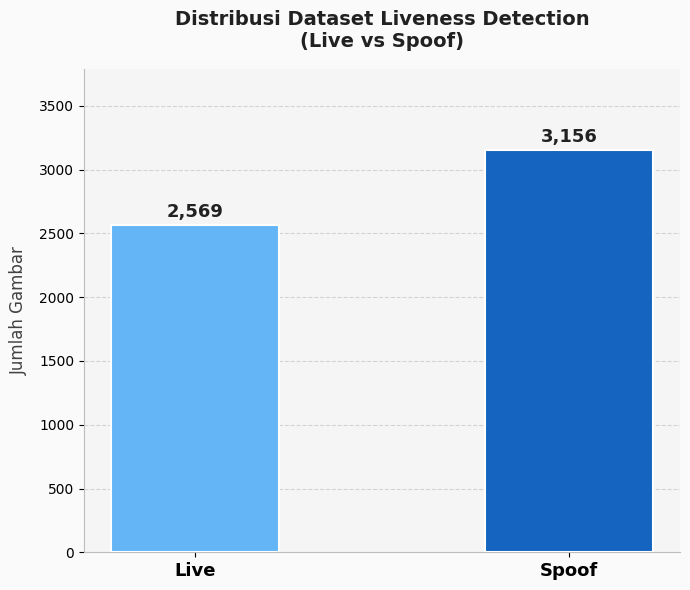

Kelas          Jumlah
------------------------------
Live            2,569
Spoof           3,156
------------------------------
TOTAL           5,725
Grafik disimpan sebagai: dataset_distribution.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Total keseluruhan: Live=2569, Spoof=3156
labels = ['Live', 'Spoof']
values = [2569, 3156]
colors = ['#64B5F6', '#1565C0']  # biru muda, biru gelap

x = np.arange(len(labels))
width = 0.45

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#F5F5F5')

bars = ax.bar(x, values, width,
              color=colors, edgecolor='white', linewidth=1.5, zorder=3)

# Label angka di atas setiap bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 30,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#212121'
    )

# Grid horizontal
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='#BDBDBD', zorder=0)
ax.set_axisbelow(True)

# Judul & label sumbu
ax.set_title(
    'Distribusi Dataset Liveness Detection\n(Live vs Spoof)',
    fontsize=14, fontweight='bold', color='#212121', pad=16
)
ax.set_ylabel('Jumlah Gambar', fontsize=12, labelpad=8, color='#424242')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.20)
ax.yaxis.set_tick_params(labelsize=10)

# Spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#BDBDBD')
ax.spines['bottom'].set_color('#BDBDBD')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 30)
print(f"{'Kelas':<10} {'Jumlah':>10}")
print('-' * 30)
for lbl, val in zip(labels, values):
    print(f"{lbl:<10} {val:>10,}")
print('-' * 30)
print(f"{'TOTAL':<10} {sum(values):>10,}")
print('=' * 30)
print('Grafik disimpan sebagai: dataset_distribution.png')


In [7]:
# Normalisasi data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Encoding label: live -> 0, spoof -> 1
le = LabelEncoder()
y_train = le.fit_transform(y_train_labels)
y_test = le.transform(y_test_labels)

# Simpan label encoder
with open("Label_encoder_liveness.pickle", "wb") as f:
    pickle.dump(le, f)

print("Classes:", le.classes_)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Classes: ['live' 'spoof']
y_train shape: (4580,)
y_test shape: (1145,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Model CNN 
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid untuk binary classification (live/spoof)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

d:\FaceAttend_VC\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# Augmentasi data (hanya untuk data training)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callbacks
checkpoint = ModelCheckpoint('liveness_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Parameter Training
epochs = 30
batch_size = 32

# Training Model
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=batch_size),
    validation_data=(x_test, y_test),
    epochs=epochs,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.6394 - loss: 1.6540
Epoch 1: val_accuracy improved from None to 0.44891, saving model to liveness_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 106s 704ms/step - accuracy: 0.6771 - loss: 0.9902 - val_accuracy: 0.4489 - val_loss: 11.8647
Epoch 2/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.7207 - loss: 0.5626
Epoch 2: val_accuracy improved from 0.44891 to 0.60349, saving model to liveness_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 111s 767ms/step - accuracy: 0.7264 - loss: 0.5555 - val_accuracy: 0.6035 - val_loss: 1.0161
Epoch 3/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.7729 - loss: 0.4870
Epoch 3: val_accuracy improved from 0.60349 to 0.61747, saving model to liveness_model.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 107s 742ms/step - accuracy: 0.7646 - loss: 0.4978 - val_accuracy: 0.6175 - val_loss: 0.9906
Epoch 4/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.7799 - loss: 0.4668
Epoch 4:

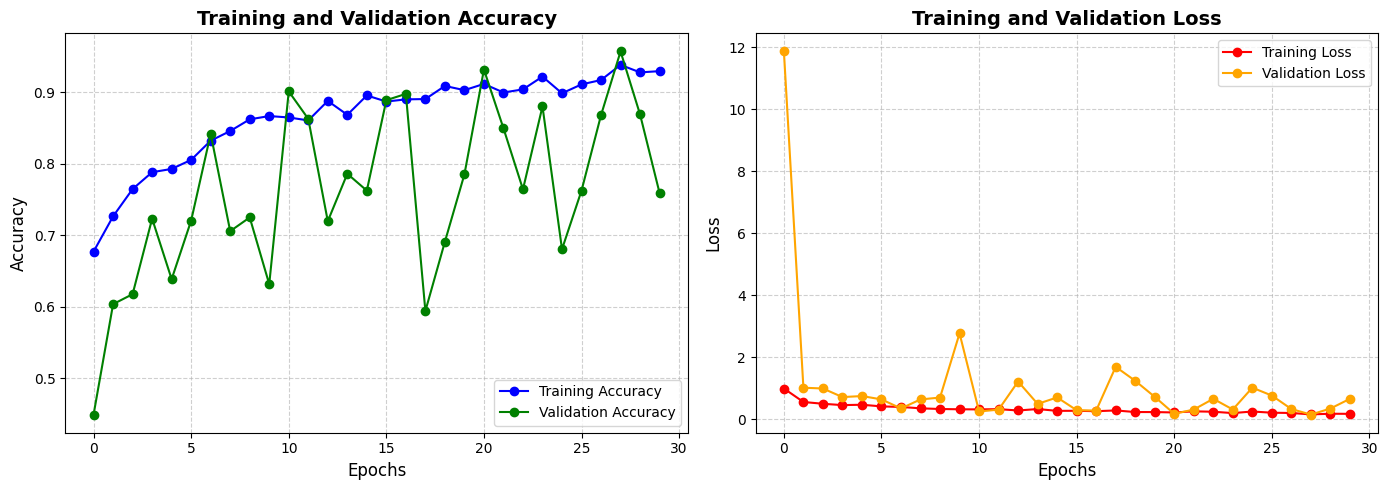

In [10]:
# ============================================================
# VISUALISASI HASIL TRAINING (Accuracy & Loss)
# ============================================================
import matplotlib.pyplot as plt

# Mendapatkan metrik dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='green', marker='o')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()


[INFO] Mengevaluasi model pada data test...
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step

=== METRIK EVALUASI ===
Accuracy  : 0.9572 (95.72%)
Precision : 0.9649 (96.49%)
Recall    : 0.9572 (95.72%)
F1-Score  : 0.9610 (96.10%)

Classification Report:
              precision    recall  f1-score   support

        Live       0.95      0.96      0.95       514
       Spoof       0.96      0.96      0.96       631

    accuracy                           0.96      1145
   macro avg       0.96      0.96      0.96      1145
weighted avg       0.96      0.96      0.96      1145



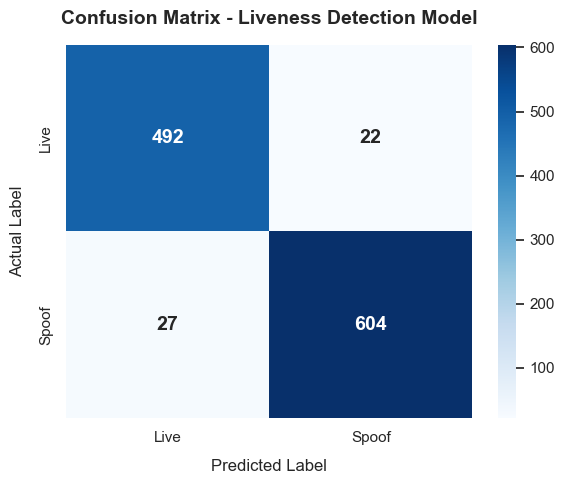

[OK] Plot confusion matrix disimpan sebagai: confusion_matrix.png


In [11]:
# ============================================================
# EVALUASI MODEL (Confusion Matrix, Accuracy, Precision, Recall, F1-Score)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Prediksi data test
print("[INFO] Mengevaluasi model pada data test...")
y_pred = model.predict(x_test)
y_pred_classes = (y_pred >= 0.5).astype(int).flatten()

# 2. Hitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

print("\n=== METRIK EVALUASI ===")
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score  : {f1:.4f} ({f1*100:.2f}%)")
print("=======================\n")

# Print classification report lengkap
print("Classification Report:")
target_names = ['Live', 'Spoof']
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# 3. Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# 4. Plot Confusion Matrix
try:
    import seaborn as sns
    plt.figure(figsize=(6, 5))
    sns.set_theme(style="white")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names,
                annot_kws={"size": 14, "weight": "bold"}, cbar=True)
    plt.title('Confusion Matrix - Liveness Detection Model', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.ylabel('Actual Label', fontsize=12, labelpad=10)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#F5F5F5')
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=target_names, yticklabels=target_names)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=11)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center", fontsize=11)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')
    ax.set_title('Confusion Matrix - Passive Liveness Detection Model', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)
    fig.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

print("[OK] Plot confusion matrix disimpan sebagai: confusion_matrix.png")


### Pengujian Model secara Real-Time
Jalankan cell di bawah ini untuk membuka webcam dan menguji model yang baru saja dilatih.

In [12]:
import cv2
import numpy as np

print("[INFO] Membuka Webcam...")
cap = cv2.VideoCapture(0)

print("Tekan 'q' pada keyboard di jendela kamera untuk keluar.")

while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(rgb_frame)
    
    for result in results:
        if result['confidence'] < 0.8:
            continue
            
        x, y, w, h = result['box']
        pad = int(min(w, h) * 0.1)
        x1, y1 = max(0, x-pad), max(0, y-pad)
        x2, y2 = min(frame.shape[1], x+w+pad), min(frame.shape[0], y+h+pad)
        
        face_crop = rgb_frame[y1:y2, x1:x2]
        if face_crop.size == 0:
            continue
            
        # Preprocessing 
        processed_face = apply_clahe_and_resize(face_crop)
        processed_face = processed_face / 255.0  # Normalisasi
        processed_face = np.expand_dims(processed_face, axis=0)
        
        # Prediksi
        pred = model.predict(processed_face, verbose=0)[0][0]
        
        if pred < 0.5:
            label = "Live"
            color = (0, 255, 0)
            confidence = (1 - pred) * 100
        else:
            label = "Spoof"
            color = (0, 0, 255)
            confidence = pred * 100
            
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        text = f"{label}: {confidence:.1f}%"
        (text_width, text_height), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame, (x1, y1 - 25), (x1 + text_width, y1), color, -1)
        cv2.putText(frame, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
    cv2.imshow('Liveness Test - Tekan Q untuk keluar', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


[INFO] Membuka Webcam...
Tekan 'q' pada keyboard di jendela kamera untuk keluar.
